In [4]:
import cv2
import numpy as np
import os
from skimage.feature import graycomatrix, graycoprops
from skimage.feature import local_binary_pattern
from sklearn.cluster import KMeans
import pandas as pd

# ===== SETTINGS =====
DATASET_PATH = "clahe_output"

GLCM_CSV = "f/glcm_features_clahe.csv"
KMEANS_CSV = "f/kmeans_features_clahe.csv"

glcm_list = []
kmeans_list = []

labels_glcm = []
labels_kmeans = []

for class_name in os.listdir(DATASET_PATH):

    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, 0)
        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        # =========================
        # 🔹 GLCM + LBP FEATURES
        # =========================

        # ----- GLCM -----
        glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4],
                            levels=256, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()

        glcm_features = np.hstack([contrast, energy, homogeneity, correlation])


        # ----- LBP -----
        radius = 1
        n_points = 8 * radius

        lbp = local_binary_pattern(img, n_points, radius, method='uniform')

        # LBP histogram
        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        # normalize
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-6)

        # =========================
        # 🔹 HISTOGRAM (ADD TO GLCM)
        # =========================
        mean = np.mean(img)
        std = np.std(img)

        hist, _ = np.histogram(img.flatten(), bins=256, range=[0,256])
        prob = hist / np.sum(hist)
        entropy = -np.sum(prob * np.log2(prob + 1e-10))

        hist_features = [mean, std, entropy]

        # =========================
        # 🔹 FINAL COMBINED FEATURES
        # =========================
        glcm_lbp_features = np.hstack([
            glcm_features,
            lbp_hist,
            hist_features   #  added
        ])

        glcm_list.append(glcm_lbp_features)
        labels_glcm.append(class_name)


        # =========================
        #  K-MEANS FEATURES (HISTOGRAM BASED)
        # =========================

        # Compute histogram
        hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

        # Create weighted samples (intensity repeated by frequency)
        samples = []
        for i in range(256):
            samples += [i] * int(hist[i])

        samples = np.array(samples).reshape(-1, 1)

        # Apply KMeans
        kmeans = KMeans(n_clusters=2, random_state=0).fit(samples)

        # Sort centers
        centers = np.sort(kmeans.cluster_centers_.flatten())
        c1, c2 = centers

        # Distance between centroids
        distance = abs(c2 - c1)

        # Get labels and counts
        labels_k = kmeans.labels_
        counts = np.bincount(labels_k)

        # Fix p1 → ensure it corresponds to smaller centroid (c1)
        if kmeans.cluster_centers_[0] < kmeans.cluster_centers_[1]:
            p1 = counts[0] / len(labels_k)
        else:
            p1 = counts[1] / len(labels_k)

        # Feature vector
        kmeans_features = [c1, c2, distance, p1]

        # Store
        kmeans_list.append(kmeans_features)
        labels_kmeans.append(class_name)



# ===== SAVE GLCM CSV =====
df_glcm = pd.DataFrame(glcm_list)
df_glcm['label'] = labels_glcm
df_glcm.to_csv(GLCM_CSV, index=False)


# ===== SAVE KMEANS CSV =====
df_kmeans = pd.DataFrame(kmeans_list)
df_kmeans['label'] = labels_kmeans
df_kmeans.to_csv(KMEANS_CSV, index=False)


print("2 CSV files saved ")

2 CSV files saved 


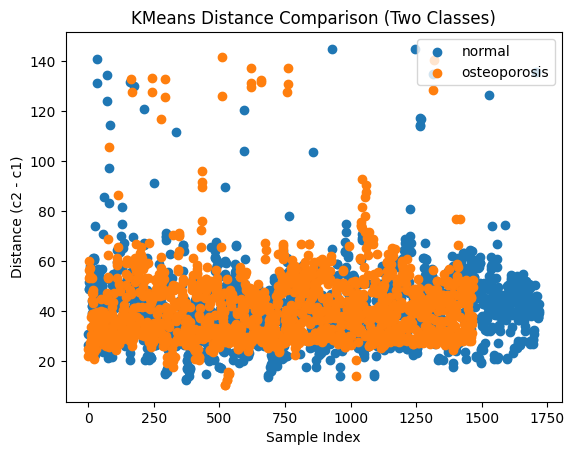

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== LOAD CSV =====
df = pd.read_csv("f/kmeans_features_clahe.csv")

# ===== CHECK LABELS =====
labels = df['label'].unique()

if len(labels) != 2:
    raise ValueError("This plot expects exactly 2 labels")

label1, label2 = labels[0], labels[1]

# ===== SPLIT DATA =====
df1 = df[df['label'] == label1]
df2 = df[df['label'] == label2]

# ===== PLOT =====
plt.figure()

# Plot distances (column index 2)
plt.scatter(range(len(df1)), df1.iloc[:, 2], label=label1)
plt.scatter(range(len(df2)), df2.iloc[:, 2], label=label2)

plt.xlabel("Sample Index")
plt.ylabel("Distance (c2 - c1)")
plt.title("KMeans Distance Comparison (Two Classes)")
plt.legend()

plt.show()

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# =====================================================
# SKLEARN MODELS
# =====================================================

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# =====================================================
# PYTORCH
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ANN MODEL
# =====================================================

class ANN(nn.Module):

    def __init__(self, input_size, num_classes):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):

        return self.network(x)

# =====================================================
# TRAIN ANN
# =====================================================

def train_ann(X_train, X_test, y_train):

    # =============================================
    # NUMPY -> TENSOR
    # =============================================

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    # =============================================
    # DATASET & DATALOADER
    # =============================================

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    # =============================================
    # MODEL
    # =============================================

    input_size = X_train.shape[1]

    num_classes = len(np.unique(y_train))

    model = ANN(
        input_size,
        num_classes
    ).to(device)

    # =============================================
    # LOSS & OPTIMIZER
    # =============================================

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # =============================================
    # TRAINING
    # =============================================

    epochs = 20

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {total_loss:.4f}"
        )

    # =============================================
    # PREDICTION
    # =============================================

    model.eval()

    with torch.no_grad():

        X_test_tensor = X_test_tensor.to(device)

        outputs = model(X_test_tensor)

        _, predicted = torch.max(outputs, 1)

        y_pred = predicted.cpu().numpy()

    return y_pred

# =====================================================
# RUN EXPERIMENT
# =====================================================

def run_experiment(file_path, dataset_name):

    print(f"\n===== {dataset_name} DATASET =====")

    # =============================================
    # LOAD DATA
    # =============================================

    df = pd.read_csv(file_path)

    # =============================================
    # FEATURES & LABELS
    # =============================================

    X = df.drop(columns=['label'])

    # Encode labels
    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        df['label']
    )

    # =============================================
    # NORMALIZATION
    # =============================================

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    # =============================================
    # TRAIN TEST SPLIT
    # =============================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # =============================================
    # MACHINE LEARNING MODELS
    # =============================================

    models = {

        "SVM": SVC(
            kernel='rbf',
            C=1,
            gamma="scale"
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "RandomForest": RandomForestClassifier(
            n_estimators=50,
            n_jobs=-1
        ),

        "LogisticRegression": LogisticRegression(
            max_iter=500
        ),

        "DecisionTree": DecisionTreeClassifier(
            max_depth=5
        ),

        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=100
        )
    }

    # =============================================
    # SKLEARN MODELS
    # =============================================

    for name, model in models.items():

        print(f"\n--- {name} ---")

        # =========================================
        # TRAIN
        # =========================================

        model.fit(X_train, y_train)

        # =========================================
        # PREDICT
        # =========================================

        y_pred = model.predict(X_test)

        # =========================================
        # METRICS
        # =========================================

        acc = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        )

        print(
            f"Acc={acc:.4f}, "
            f"Prec={precision:.4f}, "
            f"Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )

        # =========================================
        # CONFUSION MATRIX
        # =========================================

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        print("Confusion Matrix:")
        print(cm)

        # =========================================
        # CLASSIFICATION REPORT
        # =========================================

        print("Classification Report:")

        print(classification_report(
            y_test,
            y_pred
        ))

    # =============================================
    # ANN MODEL
    # =============================================

    print(f"\n--- ANN ---")

    y_pred_ann = train_ann(
        X_train,
        X_test,
        y_train
    )

    # =============================================
    # ANN METRICS
    # =============================================

    acc = accuracy_score(
        y_test,
        y_pred_ann
    )

    precision = precision_score(
        y_test,
        y_pred_ann,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_ann,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_ann,
        average='weighted',
        zero_division=0
    )

    print(
        f"Acc={acc:.4f}, "
        f"Prec={precision:.4f}, "
        f"Recall={recall:.4f}, "
        f"F1={f1:.4f}"
    )

    # =============================================
    # CONFUSION MATRIX
    # =============================================

    cm = confusion_matrix(
        y_test,
        y_pred_ann
    )

    print("Confusion Matrix:")
    print(cm)

    # =============================================
    # CLASSIFICATION REPORT
    # =============================================

    print("Classification Report:")

    print(classification_report(
        y_test,
        y_pred_ann
    ))

# =====================================================
# RUN BOTH DATASETS
# =====================================================

run_experiment(
    "f/glcm_features_clahe.csv",
    "GLCM"
)

run_experiment(
    "f/kmeans_features_clahe.csv",
    "KMeans"
)


===== GLCM DATASET =====

--- SVM ---
Acc=0.8229, Prec=0.8278, Recall=0.8229, F1=0.8231
Confusion Matrix:
[[271  73]
 [ 40 254]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       344
           1       0.78      0.86      0.82       294

    accuracy                           0.82       638
   macro avg       0.82      0.83      0.82       638
weighted avg       0.83      0.82      0.82       638


--- KNN ---
Acc=0.8213, Prec=0.8215, Recall=0.8213, F1=0.8214
Confusion Matrix:
[[285  59]
 [ 55 239]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       344
           1       0.80      0.81      0.81       294

    accuracy                           0.82       638
   macro avg       0.82      0.82      0.82       638
weighted avg       0.82      0.82      0.82       638


--- RandomForest ---
Acc=0.8276, Prec=0.8277, Recall=0.8276, F1=0

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ===== SETTINGS =====
DATASET_PATH = "clahe_output"
BATCH_SIZE = 64
EPOCHS = 10
IMG_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORMS =====
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ===== DATASET =====
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===== MODEL =====
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)   
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN().to(device)

# ===== LOSS & OPTIMIZER =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===== TRAINING =====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

# ===== EVALUATION =====
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # store for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Epoch [1/10], Loss: 26.0328
Epoch [2/10], Loss: 22.9785
Epoch [3/10], Loss: 22.1172
Epoch [4/10], Loss: 21.0266
Epoch [5/10], Loss: 20.3309
Epoch [6/10], Loss: 19.5693
Epoch [7/10], Loss: 18.7137
Epoch [8/10], Loss: 18.5147
Epoch [9/10], Loss: 17.6056
Epoch [10/10], Loss: 17.1356
Accuracy: 0.7915

Confusion Matrix:
[[236  94]
 [ 39 269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       330
           1       0.74      0.87      0.80       308

    accuracy                           0.79       638
   macro avg       0.80      0.79      0.79       638
weighted avg       0.80      0.79      0.79       638



In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ===== SETTINGS =====
DATASET_PATH = "clahe_output"
BATCH_SIZE = 64
EPOCHS = 10
IMG_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORMS =====
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ===== DATASET =====
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===== FEATURE EXTRACTION (NO PADDING) =====
def get_features(x):
    # center pixels (remove border)
    center = x[:, :, 1:-1, 1:-1]   # (B,1,126,126)

    n1 = x[:, :, :-2, :-2]   # top-left
    n2 = x[:, :, :-2, 1:-1]  # top
    n3 = x[:, :, :-2, 2:]    # top-right
    n4 = x[:, :, 1:-1, :-2]  # left
    n5 = x[:, :, 1:-1, 2:]   # right
    n6 = x[:, :, 2:, :-2]    # bottom-left
    n7 = x[:, :, 2:, 1:-1]   # bottom
    n8 = x[:, :, 2:, 2:]     # bottom-right

    features = torch.cat([
        # (center - n1), (center - n2), (center - n3),
        # (center - n4), (center - n5),
        # (center - n6), (center - n7), (center - n8)
        torch.abs(center - n1),
        torch.abs(center - n2),
        torch.abs(center - n3),

        torch.abs(center - n4),
        torch.abs(center - n5),

        torch.abs(center - n6),
        torch.abs(center - n7),
        torch.abs(center - n8)
    ], dim=1)  # (B, 8, 126, 126)

    return features

# ===== PURE ANN MODEL =====
class PureANN(nn.Module):
    def __init__(self):
        super().__init__()

        input_size = 8 * 126 * 126  

        self.fc = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 2)  
        )

    def forward(self, x):
        x = get_features(x)             
        x = x.view(x.size(0), -1)       
        x = self.fc(x)
        return x

# ===== MODEL =====
model = PureANN().to(device)

# ===== LOSS & OPTIMIZER =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===== TRAINING =====
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

# ===== EVALUATION =====
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # store for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Epoch [1/10], Loss: 51.2865
Epoch [2/10], Loss: 28.5554
Epoch [3/10], Loss: 27.4397
Epoch [4/10], Loss: 26.5414
Epoch [5/10], Loss: 25.5600
Epoch [6/10], Loss: 23.9921
Epoch [7/10], Loss: 23.8843
Epoch [8/10], Loss: 21.2144
Epoch [9/10], Loss: 20.3010
Epoch [10/10], Loss: 18.3154
Accuracy: 0.7445

Confusion Matrix:
[[232 105]
 [ 58 243]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       337
           1       0.70      0.81      0.75       301

    accuracy                           0.74       638
   macro avg       0.75      0.75      0.74       638
weighted avg       0.75      0.74      0.74       638

